# Overview

This notebook ingests data from multiple sources and formats and coverts it to a standard HuggingFace dataset format.

All datasets will have "sentence" and "audio" features. Different datasets may contain additional metadata information.

In [1]:
pip install pathlib tqdm datasets pandas soundfile librosa seaborn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import glob
from pathlib import Path
from typing import Dict, List, Tuple

from tqdm.auto import tqdm
from datasets import Dataset, DatasetDict, Features, Audio, Value
import pandas as pd

## Dependency Fixes

In [3]:
import sys
import os
import torch
import datasets

print("Python:", sys.executable)
print("Torch:", torch.__version__)
print("Datasets:", datasets.__version__)
print("LD_LIBRARY_PATH:", os.environ.get("LD_LIBRARY_PATH"))

Python: /root/miniconda3/envs/py3.10/bin/python3.10
Torch: 2.11.0+cu130
Datasets: 3.6.0
LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64


In [4]:
import os
print(os.environ["LD_LIBRARY_PATH"])

/usr/local/nvidia/lib:/usr/local/nvidia/lib64


In [5]:
import sys
print(sys.executable)

!which python
!pip show datasets

/root/miniconda3/envs/py3.10/bin/python3.10
/root/miniconda3/envs/py3.10/bin/python
Name: datasets
Version: 3.6.0
Summary: HuggingFace community-driven open-source library of datasets
Home-page: https://github.com/huggingface/datasets
Author: HuggingFace Inc.
Author-email: thomas@huggingface.co
License: Apache 2.0
Location: /root/miniconda3/envs/py3.10/lib/python3.10/site-packages
Requires: dill, filelock, fsspec, huggingface-hub, multiprocess, numpy, packaging, pandas, pyarrow, pyyaml, requests, tqdm, xxhash
Required-by: evaluate


In [14]:
!pip uninstall -y datasets torchcodec
!pip install "datasets==3.6.0"

Found existing installation: datasets 3.6.0
Uninstalling datasets-3.6.0:
  Successfully uninstalled datasets-3.6.0
  Using cached datasets-3.6.0-py3-none-any.whl.metadata (19 kB)
Using cached datasets-3.6.0-py3-none-any.whl (491 kB)

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [6]:
import datasets
print(datasets.__version__)

3.6.0


## MyST

In [7]:
def find_audio_transcript_pairs(data_dir: str) -> List[Tuple[str, str]]:
    """Find all matching .flac and .trn file pairs"""
    flac_files = glob.glob(os.path.join(data_dir, "**/*.flac"), recursive=True)
    pairs = []
    not_found_counter = 0
    for flac_file in flac_files:
        # Get corresponding .trn file
        trn_file = flac_file.replace(".flac", ".trn")

        if os.path.exists(trn_file):
            pairs.append((flac_file, trn_file))
        else:
            not_found_counter += 1

    print(
        f"Missing {not_found_counter} transcripts. These will not be included in the dataset."
    )

    return pairs


def read_transcription(trn_file: str) -> str:
    """Read transcription from .trn file"""
    try:
        with open(trn_file, "r", encoding="utf-8") as f:
            transcript = f.read().strip()

        return transcript
    except Exception as e:
        print(f"Error reading {trn_file}: {e}")
        return ""


def extract_metadata(filename: str) -> Dict[str, str]:
    """Extract metadata from filename"""
    basename = os.path.basename(filename)
    parts = basename.replace(".flac", "").replace(".trn", "").split("_")

    # Based on format: myst_002116_2014-03-04_09-24-51_LS_1.3
    metadata = {
        "speaker_id": parts[1] if len(parts) > 1 else "unknown",
        "date": parts[2] if len(parts) > 2 else "unknown",
        "time": parts[3] if len(parts) > 3 else "unknown",
        "session_type": parts[4] if len(parts) > 4 else "unknown",
        "version": parts[5] if len(parts) > 5 else "unknown",
    }

    return metadata


def create_dataset_split(data_dir: str, split_name: str) -> Dataset:
    """Create a Hugging Face dataset for one split"""
    print(f"Processing {split_name} split from {data_dir}")

    pairs = find_audio_transcript_pairs(data_dir)
    print(f"Found {len(pairs)} audio-transcript pairs")

    data = {
        "audio": [],
        "transcription": [],
        "speaker_id": [],
        "date": [],
        "time": [],
        "session_type": [],
        "version": [],
        "split": [],
    }

    for audio_file, trn_file in pairs:
        # Read transcription
        transcript = read_transcription(trn_file)

        if not transcript:  # Skip if no valid transcription
            continue

        # Extract metadata
        metadata = extract_metadata(audio_file)

        # Add to dataset
        data["audio"].append(audio_file)
        data["transcription"].append(transcript)
        data["speaker_id"].append(metadata["speaker_id"])
        data["date"].append(metadata["date"])
        data["time"].append(metadata["time"])
        data["session_type"].append(metadata["session_type"])
        data["version"].append(metadata["version"])
        data["split"].append(split_name)

    # Create dataset
    dataset = Dataset.from_dict(data)

    # Cast audio column to Audio feature (16kHz is standard for Whisper)
    dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))

    return dataset


def convert_myst_to_hf(
    base_dir: str, output_name: str = "myst-child-speech"
) -> DatasetDict:
    """Convert full MYST dataset to Hugging Face format"""

    # Define paths for each split
    splits = {
        "train": os.path.join(base_dir, "train"),
        "validation": os.path.join(
            base_dir, "development"
        ),  # or 'dev' depending on your structure
        "test": os.path.join(base_dir, "test"),
    }

    datasets = {}

    for split_name, split_path in splits.items():
        if os.path.exists(split_path):
            print(f"\nProcessing {split_name} split...")
            datasets[split_name] = create_dataset_split(split_path, split_name)
            print(f"{split_name}: {len(datasets[split_name])} samples")
        else:
            print(f"Warning: {split_path} not found, skipping {split_name}")

    # Create DatasetDict
    dataset_dict = DatasetDict(datasets)

    return dataset_dict

In [8]:
# Print current directory
print(os.getcwd())

/home


In [9]:
myst_base_dir = (
    "/home/myst-v0.4.2/data"
)

# Convert the dataset
dataset = convert_myst_to_hf(myst_base_dir)


Processing train split...
Processing train split from /home/myst-v0.4.2/data/train
Missing 104331 transcripts. These will not be included in the dataset.
Found 76992 audio-transcript pairs
train: 76924 samples

Processing validation split...
Processing validation split from /home/myst-v0.4.2/data/development
Missing 11391 transcripts. These will not be included in the dataset.
Found 12261 audio-transcript pairs
validation: 12238 samples

Processing test split...
Processing test split from /home/myst-v0.4.2/data/test
Missing 9412 transcripts. These will not be included in the dataset.
Found 13180 audio-transcript pairs
test: 13169 samples


In [10]:
# Print some statistics
print("\n=== Dataset Statistics ===")
for split, data in dataset.items():
    print(f"{split}: {len(data)} samples")

    # Show first example
    if len(data) > 0:
        example = data[0]
        print(f"  Example transcription: {example['transcription'][:100]}...")
        print(
            f"  Audio duration: {len(example['audio']['array']) / example['audio']['sampling_rate']:.2f}s"
        )


=== Dataset Statistics ===
train: 76924 samples
  Example transcription: GOOD...
  Audio duration: 1.03s
validation: 12238 samples
  Example transcription: I AM REALLY GOOD HOW ABOUT YOU...
  Audio duration: 3.19s
test: 13169 samples
  Example transcription: GOOD HOW ARE YOU...
  Audio duration: 1.75s



=== Audio Length Statistics ===

train split:
  Total samples: 1000
  Mean duration: 8.02s
  Min duration: 0.03s
  Max duration: 54.82s
  Duration distribution:
    < 5s: 487 (48.7%)
    5-30s: 488 (48.8%)
    ≥ 30s: 25 (2.5%)

validation split:
  Total samples: 1000
  Mean duration: 7.60s
  Min duration: 0.03s
  Max duration: 60.69s
  Duration distribution:
    < 5s: 494 (49.4%)
    5-30s: 482 (48.2%)
    ≥ 30s: 24 (2.4%)

test split:
  Total samples: 1000
  Mean duration: 7.63s
  Min duration: 0.06s
  Max duration: 49.78s
  Duration distribution:
    < 5s: 504 (50.4%)
    5-30s: 479 (47.9%)
    ≥ 30s: 17 (1.7%)


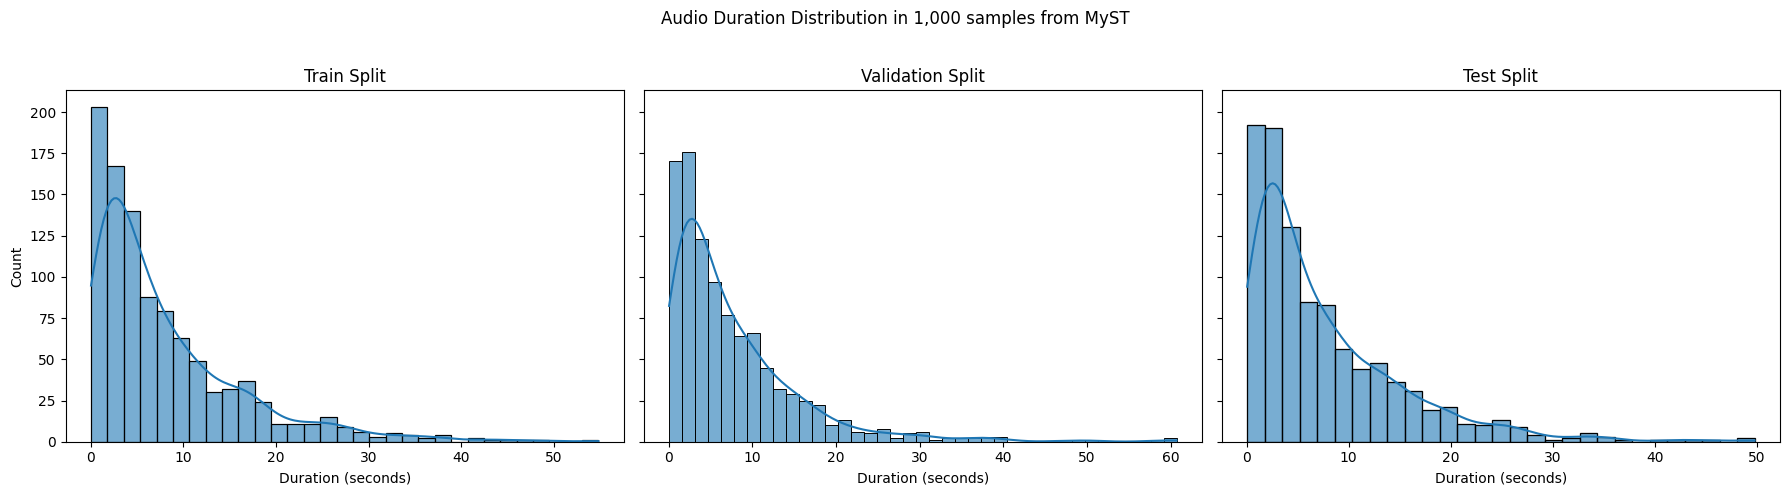

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

print("\n=== Audio Length Statistics ===")
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
plot_idx = 0
duration_stats = {}

for split, data in dataset.items():
    sample_size = min(1000, len(data))
    data_sample = data.shuffle().select(range(sample_size))
    durations = [
        len(sample["audio"]["array"]) / sample["audio"]["sampling_rate"]
        for sample in data_sample
    ]

    duration_stats[split] = durations

    print(f"\n{split} split:")
    print(f"  Total samples: {len(durations)}")
    print(f"  Mean duration: {sum(durations) / len(durations):.2f}s")
    print(f"  Min duration: {min(durations):.2f}s")
    print(f"  Max duration: {max(durations):.2f}s")

    short = sum(1 for d in durations if d < 5)
    medium = sum(1 for d in durations if 5 <= d < 30)
    long = sum(1 for d in durations if d >= 30)

    print(f"  Duration distribution:")
    print(f"    < 5s: {short} ({short / len(durations) * 100:.1f}%)")
    print(f"    5-30s: {medium} ({medium / len(durations) * 100:.1f}%)")
    print(f"    ≥ 30s: {long} ({long / len(durations) * 100:.1f}%)")

    sns.histplot(durations, alpha=0.6, label=split, kde=True, ax=axes[plot_idx])
    axes[plot_idx].set_title(f"{split.capitalize()} Split")
    axes[plot_idx].set_xlabel("Duration (seconds)")
    axes[plot_idx].set_ylabel("Count")
    plot_idx += 1

plt.suptitle("Audio Duration Distribution in 1,000 samples from MyST")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [12]:
# Save locally
myst_output_path = "/home/myst-v0.4.2/myst_dataset.ds"
dataset.save_to_disk(myst_output_path)
print(f"\nDataset saved to {myst_output_path}")

Saving the dataset (0/23 shards):   0%|          | 0/76924 [00:00<?, ? examples/s]

Saving the dataset (0/3 shards):   0%|          | 0/12238 [00:00<?, ? examples/s]

Saving the dataset (0/4 shards):   0%|          | 0/13169 [00:00<?, ? examples/s]


Dataset saved to /home/myst-v0.4.2/myst_dataset.ds
